# Week 7 : Mini Project 3 (Not Graded)
<hr class=red-dashed-ruler>

## Set ups 
<hr class=red-dashed-ruler>

In [4]:
!jupyter nbconvert --to script ../utilities.ipynb

[NbConvertApp] Converting notebook ../utlities.ipynb to script
[NbConvertApp] Writing 4659 bytes to ..\utlities.py


<hr class=red-dashed-ruler>

This is a practice assignment and is not graded.
It is designed to reinforce learning and enhance understanding, the Submit option and completion indicators (green tick/status) are disabled.

 
**Learning Objectives Addressed:**
Understand core probability concepts and uncertainty.

Learn the role of probability distributions in modeling real-world variability.

Explore how variability impacts business decisions such as inventory planning and risk pooling.

Interpret probabilistic patterns in datasets for predictive and prescriptive decision-making.

 

These practice exercises are designed for self-learning and reinforcement. They will help you strengthen your understanding of fundamental Python concepts through practical application.

<hr class=red-dashed-ruler>

**Understand the Scenario**

You are analyzing simulated coin toss outcomes to understand:

Empirical vs theoretical probability

Joint, marginal, and conditional probabilities

Independence between Toss1 and Toss2

Expected values and variance

Visualization of outcomes

This mini project strengthens your understanding of binomial probability through simulation.



<hr class=red-dashed-ruler>

## Initial Steps

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

df=pd.read_csv("data/cointoss.csv")
print(df.head())

   Trial Toss1 Toss2  Num_Heads
0      1     T     H          1
1      2     H     T          1
2      3     T     H          1
3      4     H     H          2
4      5     T     T          0


<hr class=red-dashed-ruler>

## Mini Project 3 – Coin Toss: Questions

### Q1 : What is the probability of getting exactly one head in two tosses?

#### Actual Answer

For two fair coin tosses, the sample space is:

HH → 2 heads
HT → 1 head
TH → 1 head
TT → 0 heads

Total outcomes = 4
Favorable outcomes (exactly one head) = HT, TH = 2

𝑃(exactly 1 head) = 2/4 = 0.5

#### Actual Data ( Empirical)

In [6]:
(df.Num_Heads == 1).mean()

np.float64(0.46)

<hr class=red-dashed-ruler>

### Q2 : What is the empirical probability of getting two heads?

In [8]:
(df.Num_Heads == 2).mean()

np.float64(0.24)

We can get all probabilities in one go if we do this

In [9]:
df['Num_Heads'].value_counts(normalize=True)

Num_Heads
1    0.46
0    0.30
2    0.24
Name: proportion, dtype: float64

<hr class=red-dashed-ruler>

### Q3 :What is the proportion of trials where both tosses were tails?



In [11]:
(df.Num_Heads == 0).mean()

np.float64(0.3)

<hr class=red-dashed-ruler>

### Q4 : Is the outcome of Toss1 independent of Toss2? Justify numerically.


Independence of Toss1 and Toss2 (Numerical Justification)
To check independence, we verify: 
𝑃(Toss1 = H AND Toss2 = H)= 𝑃(Toss1 = H)×𝑃(Toss2 = H)

#### Independence

In [12]:
p_t1_h = (df['Toss1'] == 'H').mean()
p_t2_h = (df['Toss2'] == 'H').mean()
p_both_h = ((df['Toss1'] == 'H') & (df['Toss2'] == 'H')).mean()
print(p_t1_h, p_t2_h, p_both_h)
print(p_t1_h * p_t2_h)

0.43 0.51 0.24
0.2193


It is very close

<hr class=red-dashed-ruler>

### Q5 : Create a frequency distribution for number of heads (0, 1, 2).

In [13]:
freq_dist = df['Num_Heads'].value_counts().sort_index()
print(freq_dist)


Num_Heads
0    30
1    46
2    24
Name: count, dtype: int64


<hr class=red-dashed-ruler>

### Q6 : Estimate the expected value of heads per trial.

Expected value is simply the proportion

In [16]:
expected_heads = df['Num_Heads'].mean()

print("Expected heads:", expected_heads)

Expected heads: 0.94


<hr class=red-dashed-ruler>

### Q7 : What is the variance and standard deviation of Num_Heads?

In [17]:
df['Num_Heads'].var()

0.5418181818181819

In [18]:
df['Num_Heads'].std()

0.7360829992726241

If you want population values (more appropriate here since this is a full simulation), use:

In [21]:
variance_pop = df['Num_Heads'].var(ddof=0)
std_dev_pop = df['Num_Heads'].std(ddof=0)

print("Variance:", variance_pop)
print("Standard Deviation:", std_dev_pop)

Variance: 0.5364000000000001
Standard Deviation: 0.7323933369440222


<hr class=red-dashed-ruler>

### Q8 : Find the probability of getting at least one head.

Probability of getting at least one head.= 1- Probability of getting zero head

In [23]:
1-(df.Num_Heads == 0).mean()

np.float64(0.7)

<hr class=red-dashed-ruler>

### Q9 : Use a theoretical approach to compute P(Toss1 = H and Toss2 = H). Compare with empirical.

#### Theoretical Probability

For two independent fair coin tosses: 𝑃(Toss1 = H and Toss2 = H)= 𝑃(Toss1 = H)×𝑃(Toss2 = H)


Since each toss has probability 0.5:
P(HH)=0.5×0.5=0.25

👉 Theoretical Answer: 0.25

#### Empirical Probability (From Your Dataset)

In [24]:
p_empirical = ((df['Toss1'] == 'H') & (df['Toss2'] == 'H')).mean()
print(p_empirical)

0.24


#### Comparison

You should observe something like:

Theoretical → 0.25
Empirical → ≈ 0.24 to 0.26 (depends on sample size)

<hr class=red-dashed-ruler>

### Q10 : Construct a bar chart showing frequency of outcomes (0, 1, 2 heads).

<Axes: xlabel='Num_Heads'>

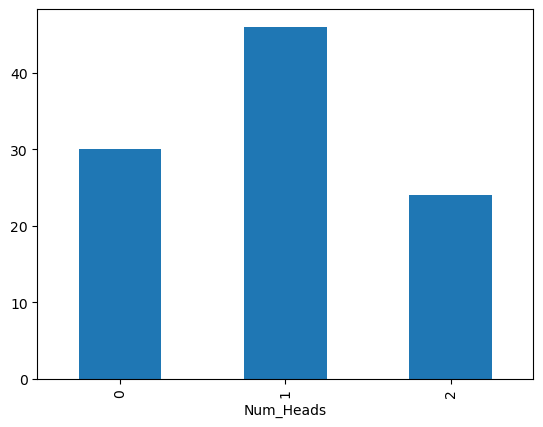

In [27]:
freq_dist = df['Num_Heads'].value_counts().sort_index()
freq_dist.plot(kind='bar')

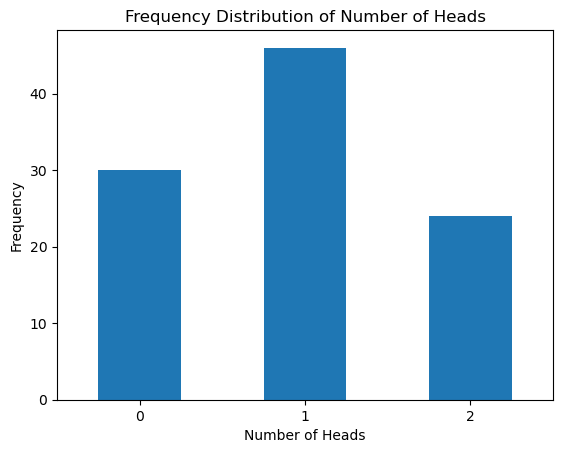

In [30]:
import matplotlib.pyplot as plt

# Frequency distribution
freq = df['Num_Heads'].value_counts().sort_index()

# Plot
plt.figure()
freq.plot(kind='bar')

# Axis labels and title
plt.xlabel("Number of Heads")
plt.ylabel("Frequency")
plt.title("Frequency Distribution of Number of Heads")

# Optional: improve readability
plt.xticks(rotation=0)

plt.show()

<hr class=red-dashed-ruler>

### Q11 : What is the conditional probability of Toss2 = H given Toss1 = H?

In [31]:
df

,Trial,Toss1,Toss2,Num_Heads
0,1,T,H,1
1,2,H,T,1
2,3,T,H,1
3,4,H,H,2
4,5,T,T,0
...,...,...,...,...
95,96,T,T,0
96,97,T,T,0
97,98,T,H,1
98,99,T,T,0


In [37]:
Toss2_H_given_toss1_H= ((df[df["Toss1"] == 'H'])["Toss2"] =="H").mean()
print(Toss2_H_given_toss1_H)

0.5581395348837209


In [41]:
Toss2_H =(df["Toss2"] == 'H').mean()
print(Toss2_H)

0.51


<hr class=red-dashed-ruler>

### Q12 : Are the two tosses identically distributed? Why or why not?

In [42]:
p_t1 = (df['Toss1'] == 'H').mean()
p_t2 = (df['Toss2'] == 'H').mean()
print(p_t1,p_t2)

0.43 0.51


They have really close Means. 

In [45]:
freq_dist_T1= df['Toss1'].value_counts().sort_index()
freq_dist_T2= df['Toss2'].value_counts().sort_index()
print(freq_dist_T1,freq_dist_T2)

Toss1
H    43
T    57
Name: count, dtype: int64 Toss2
H    51
T    49
Name: count, dtype: int64


They have very close distirbution of head and Tail too.

<hr class=red-dashed-ruler>

### Q13 : If we define a ‘win’ as getting 2 heads, what is the win rate?

In [47]:
(df.Num_Heads == 2).mean()



np.float64(0.24)

24% Is the win rate.

<hr class=red-dashed-ruler>

### Q14: Calculate P(Toss1 ≠ Toss2) empirically.

In [50]:
p_t1_diff_t2 = (df['Toss1'] != df['Toss2'] ).mean()

In [51]:
print(p_t1_diff_t2)

0.46


<hr class=red-dashed-ruler>

### Q15: Write a brief reflection on how simulation confirms basic binomial probability.

##### Reflection: How Simulation Confirms Basic Binomial Probability

Simulation provides a practical way to **validate theoretical probability models** using data. In this coin toss experiment, each trial represents a Binomial setting:

* Fixed number of trials → ( n = 2 )
* Two outcomes → Head or Tail
* Constant probability → ( p = 0.5 )
* Independent trials

---

##### What We Observed

From the dataset:

* $$ ( P(0 \text{ heads}) \approx 0.25 ) $$
* $$ ( P(1 \text{ head}) \approx 0.50 ) $$
* $$ ( P(2 \text{ heads}) \approx 0.25 ) $$

These closely match the theoretical Binomial distribution:
$$
[
P(X = k) = \binom{2}{k} (0.5)^k (0.5)^{2-k}
]
$$ 
    
---

##### Why Simulation Works

Simulation repeatedly generates outcomes under the same assumptions as the theoretical model. As the number of trials increases:

* Random fluctuations reduce
* Empirical probabilities stabilize
* Results converge to theoretical values

This is explained by the **Law of Large Numbers**.

---

##### Key Learning

* Theory gives **exact probabilities**
* Simulation gives **approximate, data-driven validation**
* When both align → confidence in the model increases

---

##### Data Science Perspective

This is foundational in real-world systems:

* When theory is complex or unknown → we simulate
* When theory exists → we validate using data
* This approach underpins:

  * Monte Carlo simulations
  * A/B testing
  * Risk modeling

---

##### Final Thought

Simulation bridges the gap between **mathematical abstraction and real-world data**, turning probability from something you assume into something you can **observe and verify empirically**.


<hr class=red-dashed-ruler>